In [1]:
# Cell 1 — Imports and Load Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import mean_squared_error as MSE, mean_absolute_error as MAE, r2_score as R2
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed_train.csv')
print(df.shape)

X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

(1308, 220)
Train: (1046, 219), Test: (262, 219)


# House Price Prediction — Model Evaluation

This notebook performs a comprehensive diagnostic evaluation of the trained models
from `03_Models.ipynb`. Rather than comparing summary metrics, the focus here is
on understanding model behavior: where predictions fail, why they fail, which
features drive them, and whether they generalize reliably to unseen data.

**Models evaluated:** Ridge (α=10), Lasso (α=0.005), Random Forest, XGBoost  
**Dataset:** Half dataset — `processed_train.csv` (1308 rows, 220 features)  
**Train/Test split:** 1046 / 262 (80/20, random_state=42)

---

### Evaluation Structure

1. Retrain best models and generate predictions
2. Model performance summary
3. Residual analysis
4. Predicted vs actual analysis
5. Error distribution by price segment
6. Cross-validation stability
7. Learning curves
8. Feature importance
9. Worst predictions analysis

In [2]:
# Cell 2 — Retrain All Models

# Ridge
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train_log)
y_pred_ridge = ridge.predict(X_test)

# Lasso
lasso = Lasso(alpha=0.005, max_iter=10000)
lasso.fit(X_train_scaled, y_train_log)
y_pred_lasso = lasso.predict(X_test_scaled)

# Random Forest
rf = RandomForestRegressor(
    n_estimators=300, max_depth=20, max_features='sqrt',
    min_samples_leaf=1, min_samples_split=2,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train_log)
y_pred_rf = rf.predict(X_test)

# XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.8, random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train_log)
y_pred_xgb = xgb_model.predict(X_test)

print('All models trained.')

All models trained.


## 1. Model Performance Summary

A consolidated view of all evaluation metrics across the four models. All predictions
are made in log-transformed price space and evaluated against log-transformed actuals.
RMSE and MAE in log scale can be interpreted as approximate percentage errors in
original price space.

In [3]:
# Cell 3 — Performance Summary Table

models = {
    'Ridge':         y_pred_ridge,
    'Lasso':         y_pred_lasso,
    'Random Forest': y_pred_rf,
    'XGBoost':       y_pred_xgb
}

results = []
for name, y_pred in models.items():
    rmse = np.sqrt(MSE(y_test_log, y_pred))
    mae  = MAE(y_test_log, y_pred)
    r2   = R2(y_test_log, y_pred)
    # MAPE in original price space
    y_pred_orig = np.expm1(y_pred)
    mape = np.mean(np.abs((y_test - y_pred_orig) / y_test)) * 100
    results.append({'Model': name, 'R²': round(r2,4), 'RMSE': round(rmse,4),
                    'MAE': round(mae,4), 'MAPE (%)': round(mape,2)})

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print(results_df.to_string(index=False))

        Model     R²   RMSE    MAE  MAPE (%)
        Ridge 0.8765 0.1311 0.0846      8.86
        Lasso 0.8758 0.1315 0.0829      8.77
      XGBoost 0.8616 0.1388 0.0911      9.49
Random Forest 0.8404 0.1490 0.0950     10.00


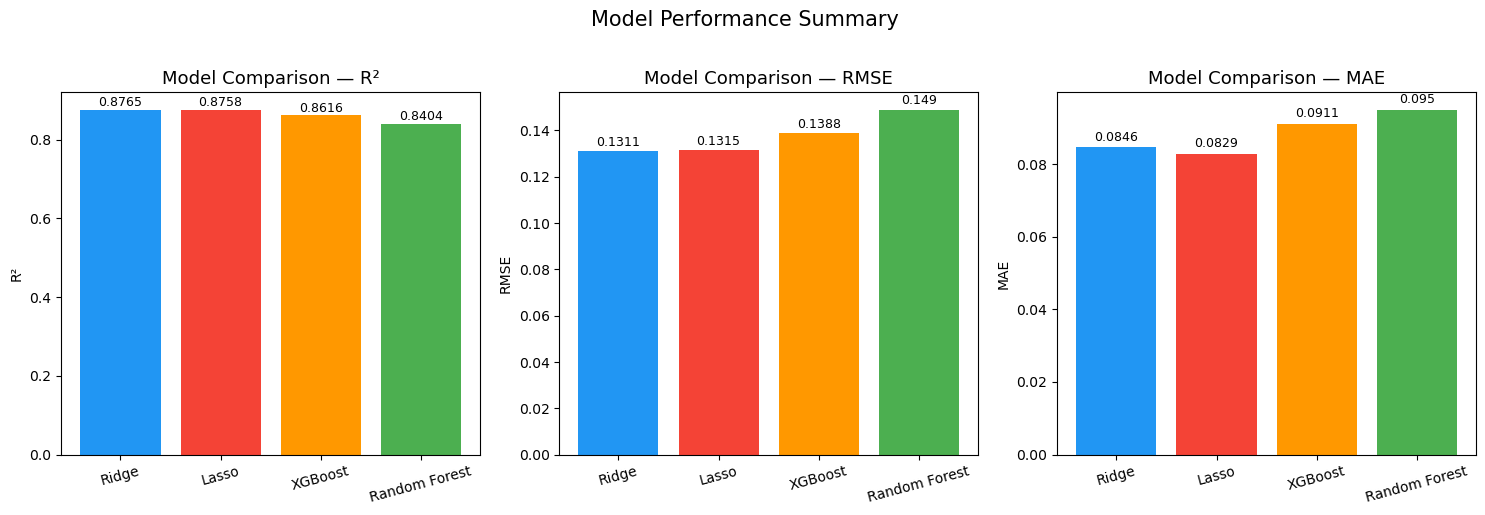

In [4]:
# Cell 4 — Performance Bar Chart

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['R²', 'RMSE', 'MAE']
colors  = ['#2196F3', '#F44336', '#FF9800', '#4CAF50']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors)
    ax.set_title(f'Model Comparison — {metric}', fontsize=13)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                str(val), ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Performance Summary', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 2. Residual Analysis

Residuals are the difference between actual and predicted values in log space:
`residual = y_actual - y_predicted`

A well-calibrated model should have residuals that are:
- **Randomly scattered** around zero with no visible pattern
- **Normally distributed** with mean ≈ 0
- **Homoscedastic** — constant variance regardless of predicted value

Any systematic pattern in residuals indicates the model is missing structure in
the data — either a non-linear relationship, an interaction effect, or a bias
toward certain price ranges.

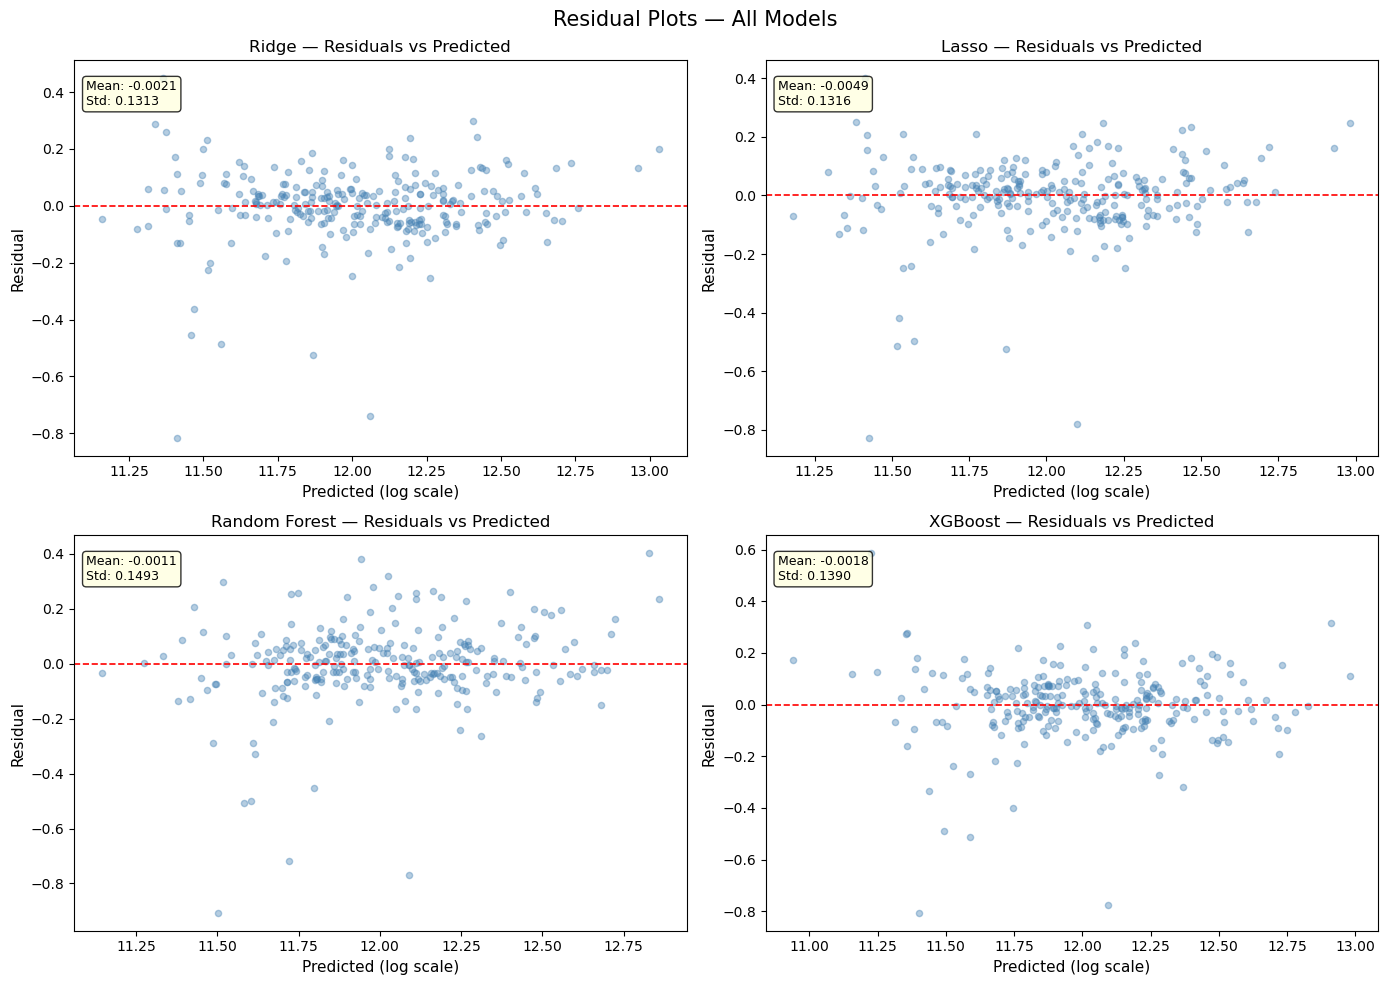

In [5]:
# Cell 5 — Residual Plots (Residuals vs Predicted)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, models.items()):
    residuals = y_test_log - y_pred
    ax.scatter(y_pred, residuals, alpha=0.4, s=20, color='steelblue')
    ax.axhline(0, color='red', linewidth=1.2, linestyle='--')
    ax.set_xlabel('Predicted (log scale)', fontsize=11)
    ax.set_ylabel('Residual', fontsize=11)
    ax.set_title(f'{name} — Residuals vs Predicted', fontsize=12)
    ax.text(0.02, 0.95, f'Mean: {residuals.mean():.4f}\nStd: {residuals.std():.4f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Residual Plots — All Models', fontsize=15)
plt.tight_layout()
plt.show()

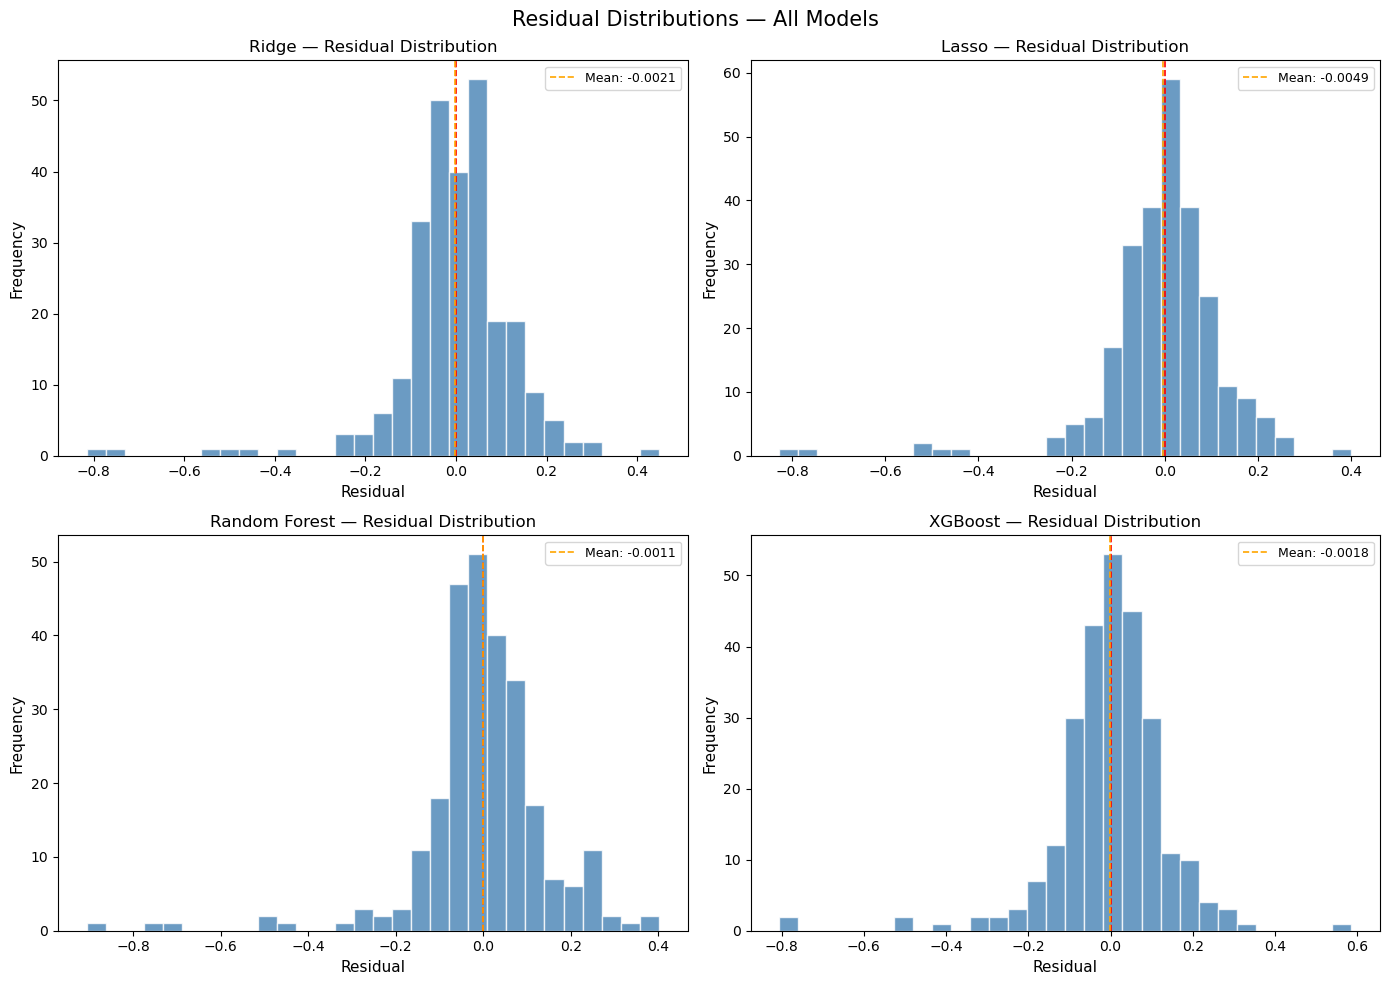

In [6]:
# Cell 6 — Residual Distribution Plots

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, models.items()):
    residuals = y_test_log - y_pred
    ax.hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linewidth=1.2, linestyle='--')
    ax.axvline(residuals.mean(), color='orange', linewidth=1.2,
               linestyle='--', label=f'Mean: {residuals.mean():.4f}')
    ax.set_xlabel('Residual', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{name} — Residual Distribution', fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle('Residual Distributions — All Models', fontsize=15)
plt.tight_layout()
plt.show()

## 3. Predicted vs Actual

Plotting predicted against actual values reveals how well the model tracks true
prices across the full range. The diagonal line represents a perfect prediction
(predicted = actual). Points above the line indicate underprediction; points below
indicate overprediction.

Systematic deviation from the diagonal in specific price ranges reveals where each
model struggles — commonly at the extremes (very cheap or very expensive houses),
where training data is sparse.

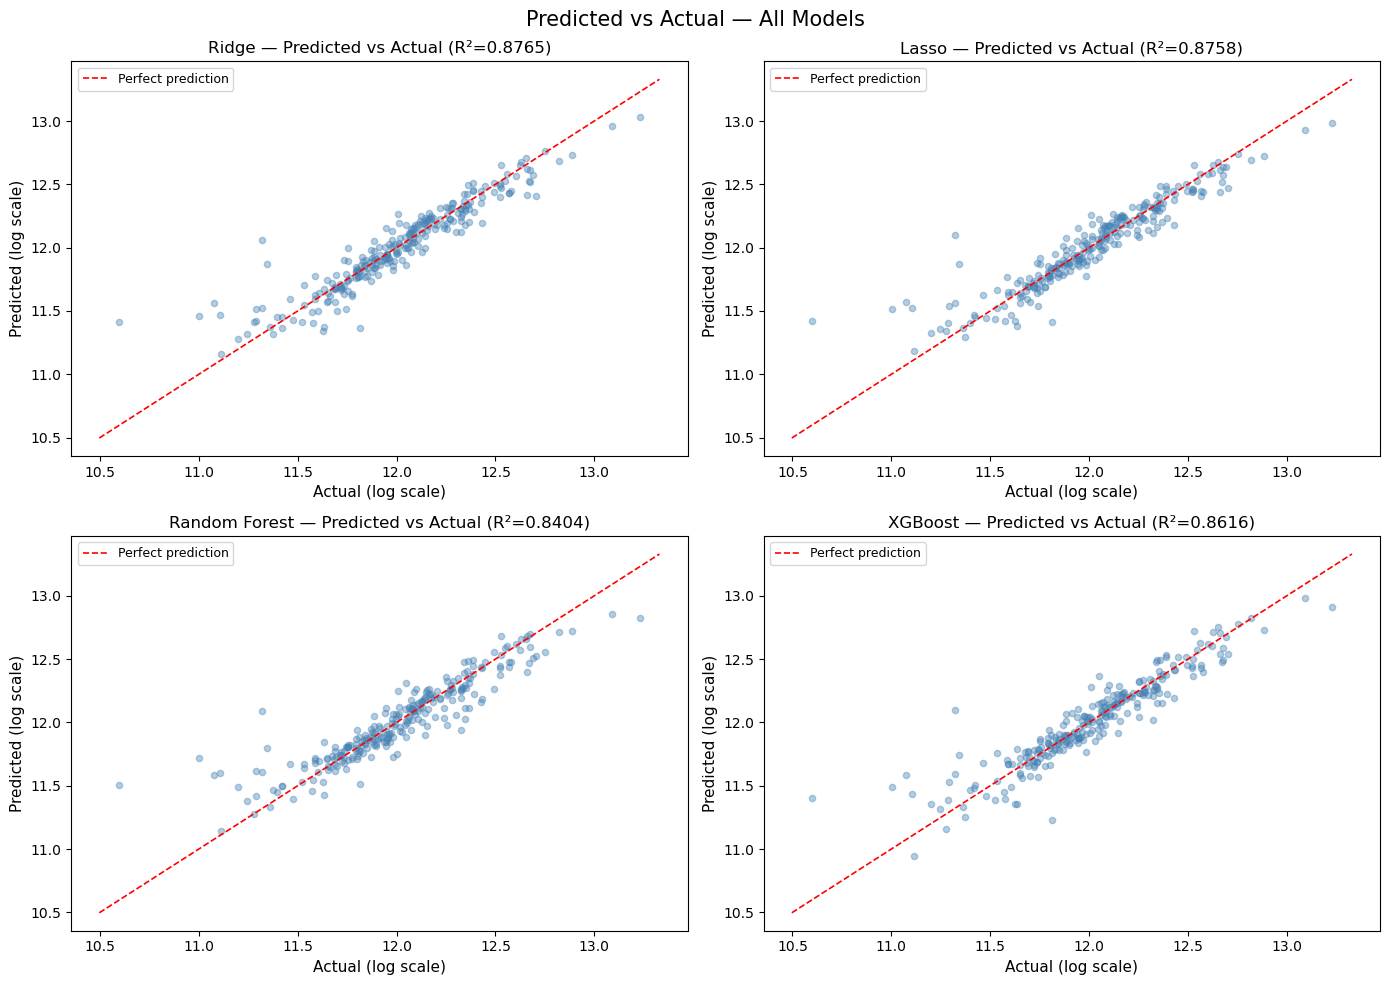

In [7]:
# Cell 7 — Predicted vs Actual Plots

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, models.items()):
    ax.scatter(y_test_log, y_pred, alpha=0.4, s=20, color='steelblue')
    lims = [min(y_test_log.min(), y_pred.min()) - 0.1,
            max(y_test_log.max(), y_pred.max()) + 0.1]
    ax.plot(lims, lims, 'r--', linewidth=1.2, label='Perfect prediction')
    r2 = R2(y_test_log, y_pred)
    ax.set_xlabel('Actual (log scale)', fontsize=11)
    ax.set_ylabel('Predicted (log scale)', fontsize=11)
    ax.set_title(f'{name} — Predicted vs Actual (R²={r2:.4f})', fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle('Predicted vs Actual — All Models', fontsize=15)
plt.tight_layout()
plt.show()

## 4. Error Distribution by Price Segment

A model that performs well on average may still fail systematically in specific
price ranges. This section segments the test set into low, mid, and high price
brackets and computes MAE separately for each — revealing whether prediction
quality is uniform or concentrated in certain areas.

High-value properties are typically harder to predict due to their unique
characteristics and sparse representation in training data.

Mean Absolute Error by Price Segment (Original Scale):
segment        Low (<130k)  Mid (130k–215k)  High (>215k)
Ridge              13477.0          10222.0       23617.0
Lasso              12926.0          10435.0       22675.0
Random Forest      13318.0          11489.0       30321.0
XGBoost            13594.0          11294.0       25525.0


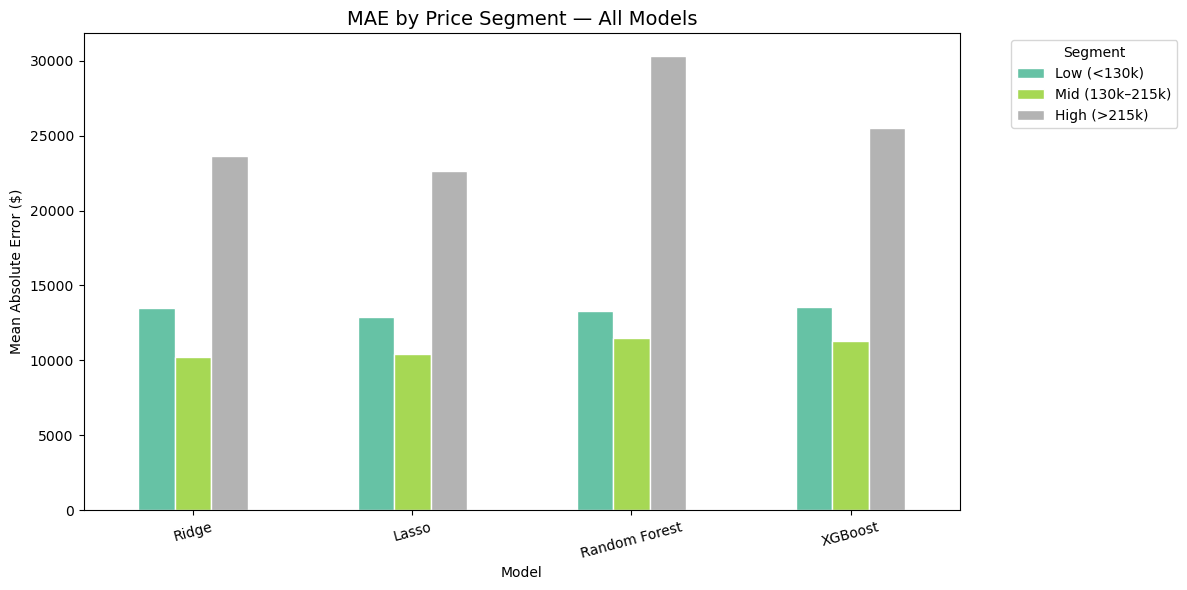

In [9]:
# Cell 8 — Error by Price Segment

# define segments on actual prices
y_test_orig = y_test.copy()
bins   = [0, 130000, 215000, np.inf]
labels = ['Low (<130k)', 'Mid (130k–215k)', 'High (>215k)']
segments = pd.cut(y_test_orig, bins=bins, labels=labels)

segment_errors = {}

for name, y_pred in models.items():
    y_pred_orig = np.expm1(y_pred)
    abs_errors  = np.abs(y_test_orig.values - y_pred_orig)
    seg_df = pd.DataFrame({'segment': segments.values, 'abs_error': abs_errors})
    segment_errors[name] = seg_df.groupby('segment')['abs_error'].mean()

seg_df_plot = pd.DataFrame(segment_errors).T
print('Mean Absolute Error by Price Segment (Original Scale):')
print(seg_df_plot.round(0))

seg_df_plot.plot(kind='bar', figsize=(12, 6), colormap='Set2', edgecolor='white')
plt.title('MAE by Price Segment — All Models', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Mean Absolute Error ($)')
plt.xticks(rotation=15)
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. Cross-Validation Stability

A single train/test split can be misleading — a model might perform well by chance
depending on which samples end up in the test set. 5-fold cross-validation evaluates
each model on 5 different train/test splits and reports mean R² and standard deviation.

A high std dev indicates the model's performance is sensitive to which data it sees —
a sign of overfitting or high variance. A low std dev with high mean indicates
consistent, reliable generalization.

In [11]:
# Cell 9 — Cross Validation Scores

cv_models = {
    'Ridge':         Ridge(alpha=10),
    'Lasso':         Lasso(alpha=0.005, max_iter=10000),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=20,
                        max_features='sqrt', random_state=42, n_jobs=-1),
    'XGBoost':       xgb.XGBRegressor(n_estimators=300, max_depth=3,
                        learning_rate=0.05, subsample=0.8,
                        random_state=42, n_jobs=-1, verbosity=0)
}

print(f'{"Model":<20} {"Mean R²":>10} {"Std Dev":>10} {"Min":>10} {"Max":>10}')
print('-' * 60)

cv_results = {}
for name, model in cv_models.items():
    X_cv = X_train_scaled if name == 'Lasso' else X_train
    scores = cross_val_score(model, X_cv, y_train_log, cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<20} {scores.mean():>10.4f} {scores.std():>10.4f} '
          f'{scores.min():>10.4f} {scores.max():>10.4f}')

Model                   Mean R²    Std Dev        Min        Max
------------------------------------------------------------
Ridge                    0.9110     0.0136     0.8896     0.9263
Lasso                    0.9122     0.0144     0.8926     0.9308
Random Forest            0.8770     0.0226     0.8483     0.9133
XGBoost                  0.8996     0.0169     0.8724     0.9183


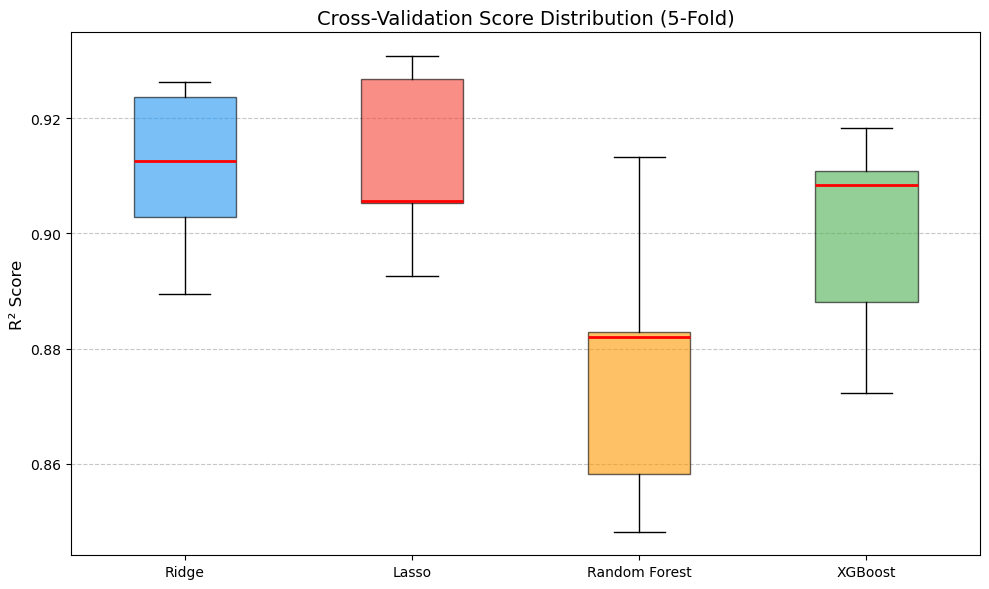

In [12]:
# Cell 10 — CV Score Box Plot

fig, ax = plt.subplots(figsize=(10, 6))

cv_data   = [cv_results[name] for name in cv_models]
cv_labels = list(cv_models.keys())

bp = ax.boxplot(cv_data, labels=cv_labels, patch_artist=True,
                medianprops=dict(color='red', linewidth=2))

colors = ['#2196F3', '#F44336', '#FF9800', '#4CAF50']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Cross-Validation Score Distribution (5-Fold)', fontsize=14)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6. Learning Curves

A learning curve plots model performance against training set size. It answers:
*does this model benefit from more data, or has it already plateaued?*

- If training score >> validation score: **overfitting** — model needs more data
  or stronger regularization
- If both scores are low and converging: **underfitting** — model lacks capacity
- If both scores are high and converging: **good fit** — model is well-calibrated

Given the limited dataset size (1046 training samples), learning curves are
particularly informative here — they directly show whether each model is data-hungry.

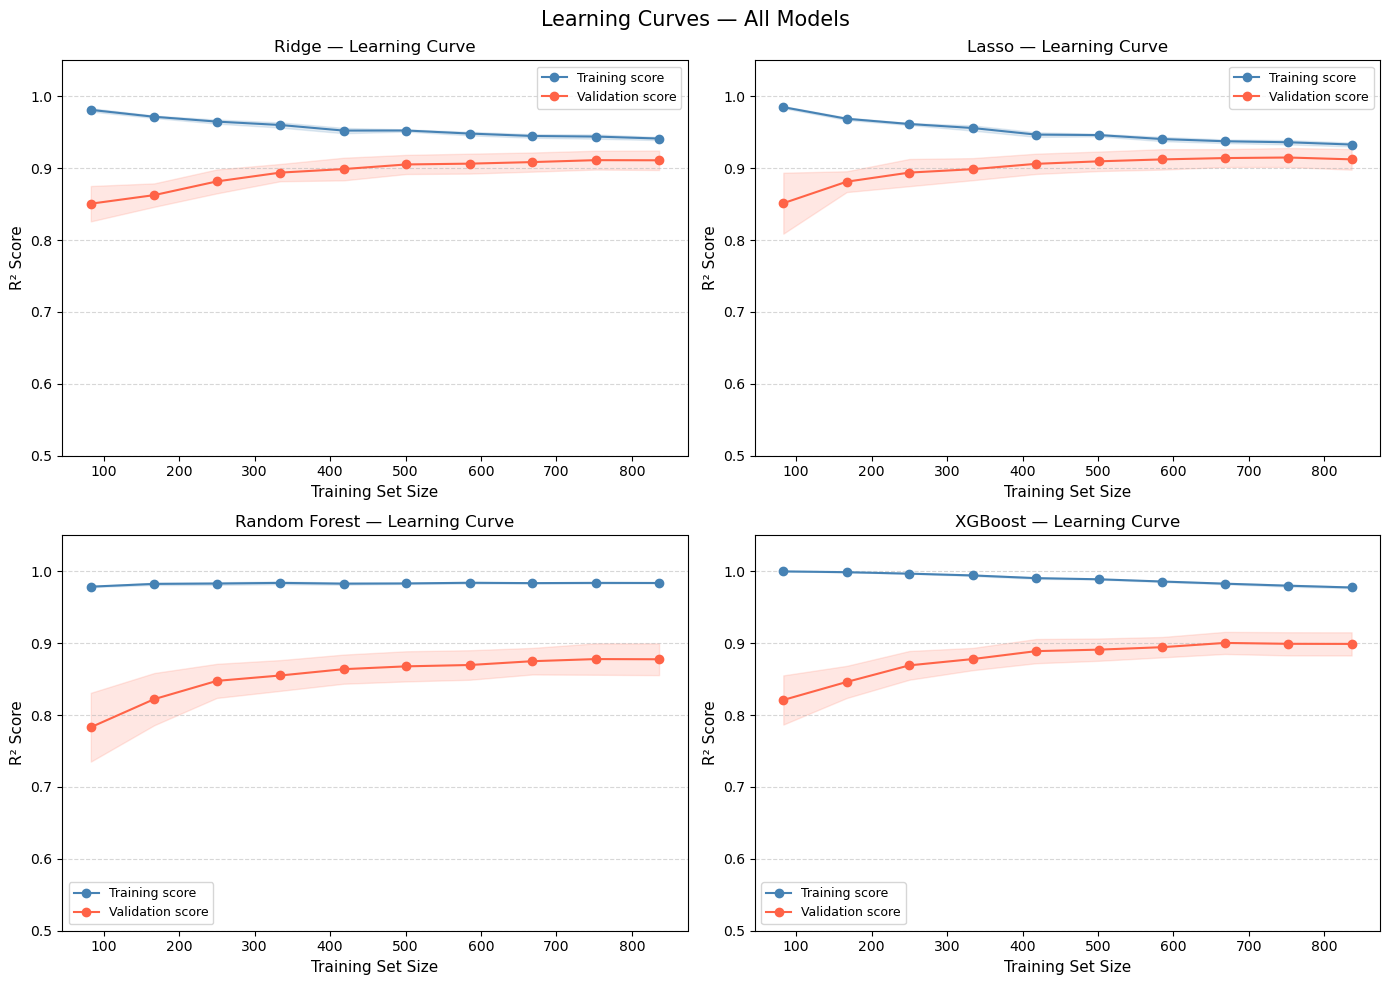

In [14]:
# Cell 11 — Learning Curves

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

train_sizes = np.linspace(0.1, 1.0, 10)

for ax, (name, model) in zip(axes, cv_models.items()):
    X_lc = X_train_scaled if name == 'Lasso' else X_train

    train_sz, train_sc, val_sc = learning_curve(
        model, X_lc, y_train_log,
        train_sizes=train_sizes, cv=5,
        scoring='r2', n_jobs=-1
    )

    train_mean = train_sc.mean(axis=1)
    train_std  = train_sc.std(axis=1)
    val_mean   = val_sc.mean(axis=1)
    val_std    = val_sc.std(axis=1)

    ax.plot(train_sz, train_mean, 'o-', color='steelblue', label='Training score')
    ax.fill_between(train_sz, train_mean - train_std,
                    train_mean + train_std, alpha=0.15, color='steelblue')
    ax.plot(train_sz, val_mean, 'o-', color='tomato', label='Validation score')
    ax.fill_between(train_sz, val_mean - val_std,
                    val_mean + val_std, alpha=0.15, color='tomato')

    ax.set_xlabel('Training Set Size', fontsize=11)
    ax.set_ylabel('R² Score', fontsize=11)
    ax.set_title(f'{name} — Learning Curve', fontsize=12)
    ax.legend(fontsize=9)
    ax.set_ylim([0.5, 1.05])
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Learning Curves — All Models', fontsize=15)
plt.tight_layout()
plt.show()

## 7. Feature Importance

Feature importance reveals which variables each model relies on most heavily
when making predictions. This is both a model diagnostic (do the important features
make domain sense?) and a data insight (what actually drives house prices in Ames?).

- **Ridge:** uses absolute coefficient values (on scaled features) as importance
- **Lasso:** same, but many coefficients are exactly zero — directly shows selected features
- **Random Forest:** uses mean decrease in impurity across all trees
- **XGBoost:** uses gain — total improvement in loss attributed to each feature

Note that importance metrics are not directly comparable across model types —
they measure different things. Each is valid within its own model's context.

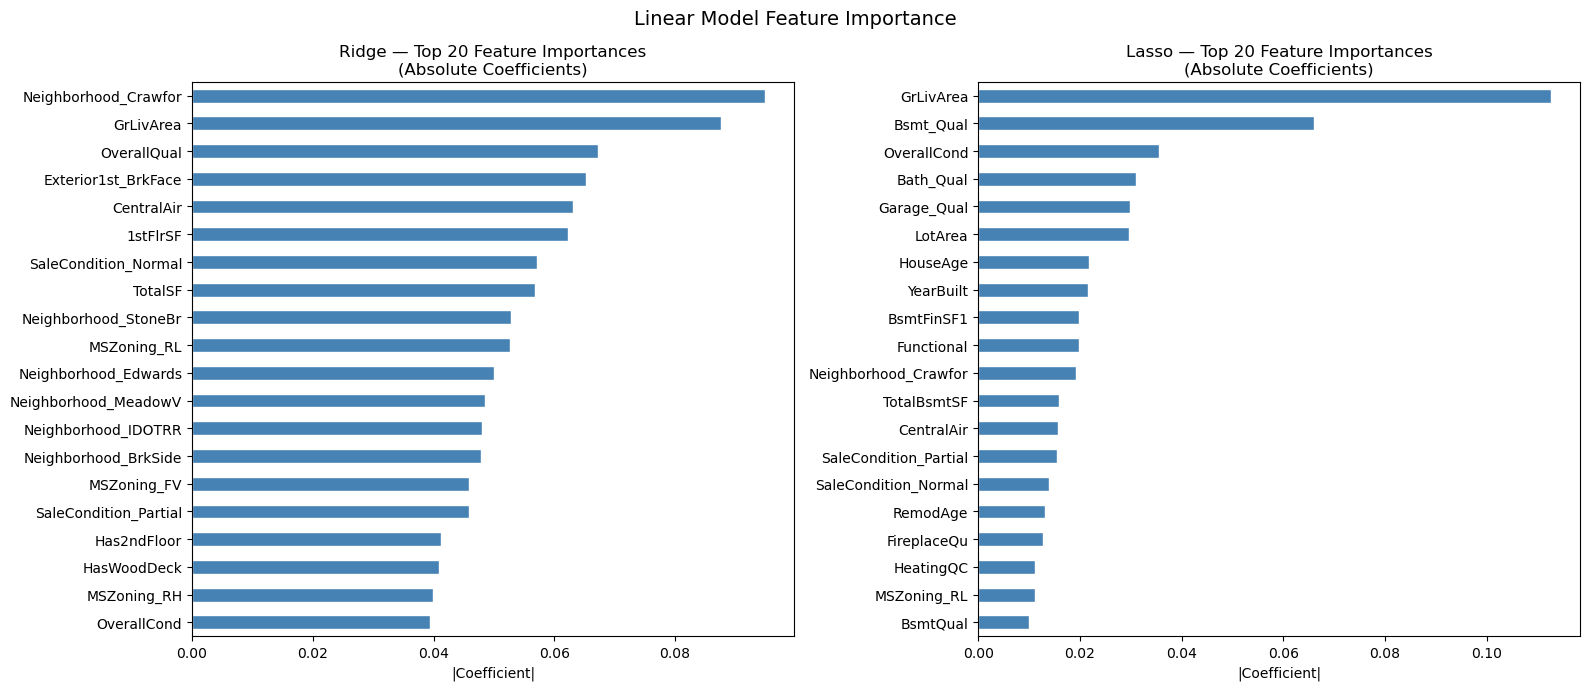

In [16]:
# Cell 12 — Feature Importance: Ridge and Lasso Coefficients

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
feature_names = X_train.columns

for ax, (name, model, X_sc) in zip(axes, [
    ('Ridge', ridge, X_test),
    ('Lasso', lasso, X_test_scaled)
]):
    coef = pd.Series(np.abs(model.coef_), index=feature_names)
    top20 = coef.nlargest(20)
    top20.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{name} — Top 20 Feature Importances\n(Absolute Coefficients)', fontsize=12)
    ax.set_xlabel('|Coefficient|')

plt.suptitle('Linear Model Feature Importance', fontsize=14)
plt.tight_layout()
plt.show()

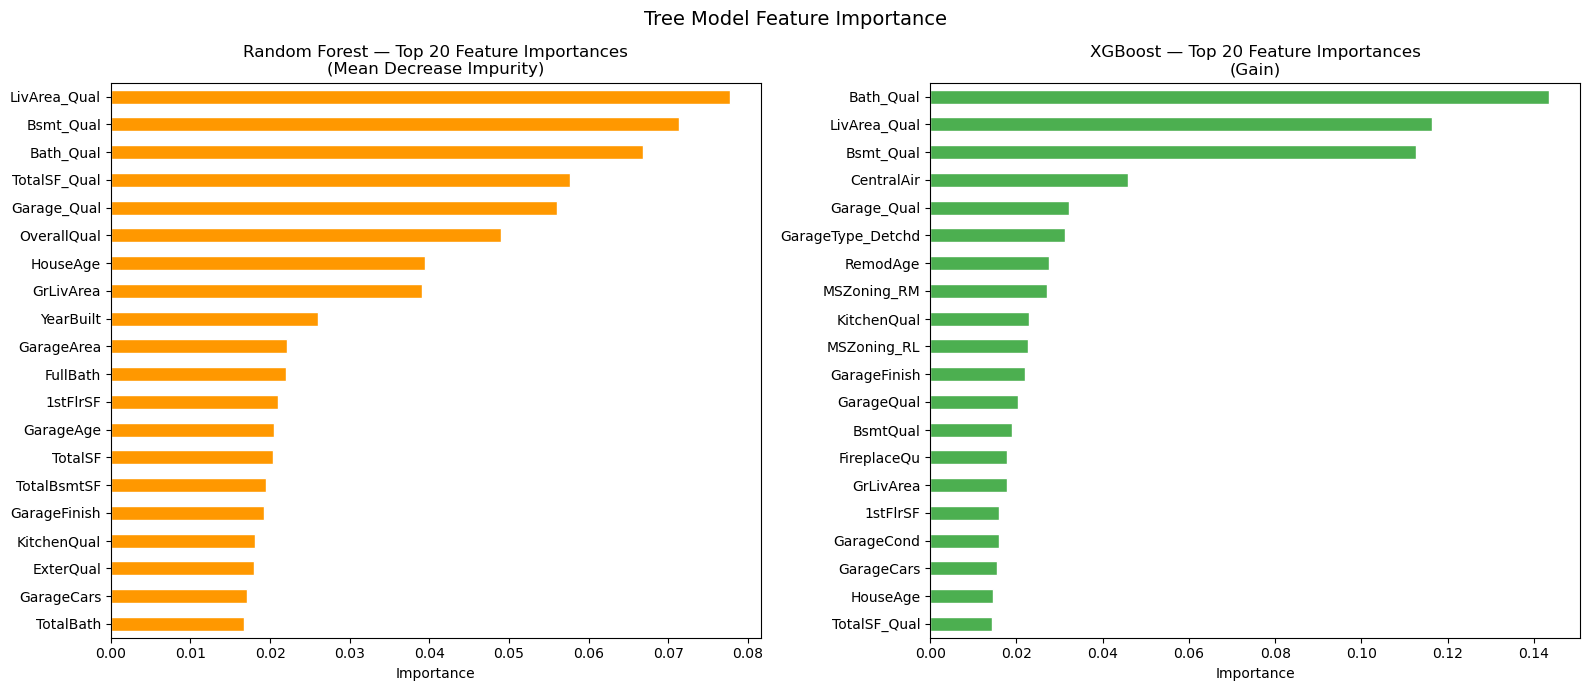

In [17]:
# Cell 13 — Feature Importance: RF and XGBoost

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
feature_names = X_train.columns

# Random Forest
rf_importance = pd.Series(rf.feature_importances_, index=feature_names)
rf_top20 = rf_importance.nlargest(20).sort_values()
rf_top20.plot(kind='barh', ax=axes[0], color='#FF9800', edgecolor='white')
axes[0].set_title('Random Forest — Top 20 Feature Importances\n(Mean Decrease Impurity)', fontsize=12)
axes[0].set_xlabel('Importance')

# XGBoost
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_names)
xgb_top20 = xgb_importance.nlargest(20).sort_values()
xgb_top20.plot(kind='barh', ax=axes[1], color='#4CAF50', edgecolor='white')
axes[1].set_title('XGBoost — Top 20 Feature Importances\n(Gain)', fontsize=12)
axes[1].set_xlabel('Importance')

plt.suptitle('Tree Model Feature Importance', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Worst Predictions Analysis

Examining the cases where each model fails most severely reveals systematic blind
spots. If the worst predictions cluster around certain neighborhoods, house styles,
or price ranges, it indicates the model lacks sufficient representation or
appropriate features for those subgroups.

This analysis uses the best overall model (Ridge) to identify the 10 worst
predictions on the test set, then examines their characteristics.

In [20]:
# Cell 14 — Worst Predictions Analysis (Ridge)

residuals_ridge = np.abs(y_test_log - y_pred_ridge)

test_analysis = X_test.copy()
test_analysis['ActualPrice']    = y_test.values
test_analysis['PredictedPrice'] = np.expm1(y_pred_ridge)
test_analysis['AbsError']       = np.abs(y_test.values - test_analysis['PredictedPrice'])
test_analysis['PctError']       = (test_analysis['AbsError'] / y_test.values) * 100
test_analysis['Residual_log']   = y_test_log.values - y_pred_ridge

worst10 = test_analysis.nlargest(10, 'AbsError')

display_cols = ['ActualPrice', 'PredictedPrice', 'AbsError', 'PctError',
                'OverallQual', 'GrLivArea']

print('Top 10 Worst Predictions (Ridge):')
print(worst10[display_cols].round(0).to_string())

Top 10 Worst Predictions (Ridge):
      ActualPrice  PredictedPrice  AbsError  PctError  OverallQual  GrLivArea
944        556581        456084.0  100497.0      18.0            9        8.0
573         82500        172841.0   90341.0     110.0            7        7.0
802        328900        244054.0   84846.0      26.0            9        7.0
174        315000        247354.0   67646.0      21.0            8        8.0
723        485000        425379.0   59621.0      12.0            9        8.0
1302        84500        142821.0   58321.0      69.0            5        7.0
342        394432        339163.0   55269.0      14.0            9        8.0
783        250580        197758.0   52822.0      21.0            7        7.0
29          40000         90438.0   50438.0     126.0            4        7.0
879        135000         86238.0   48762.0      36.0            4        7.0


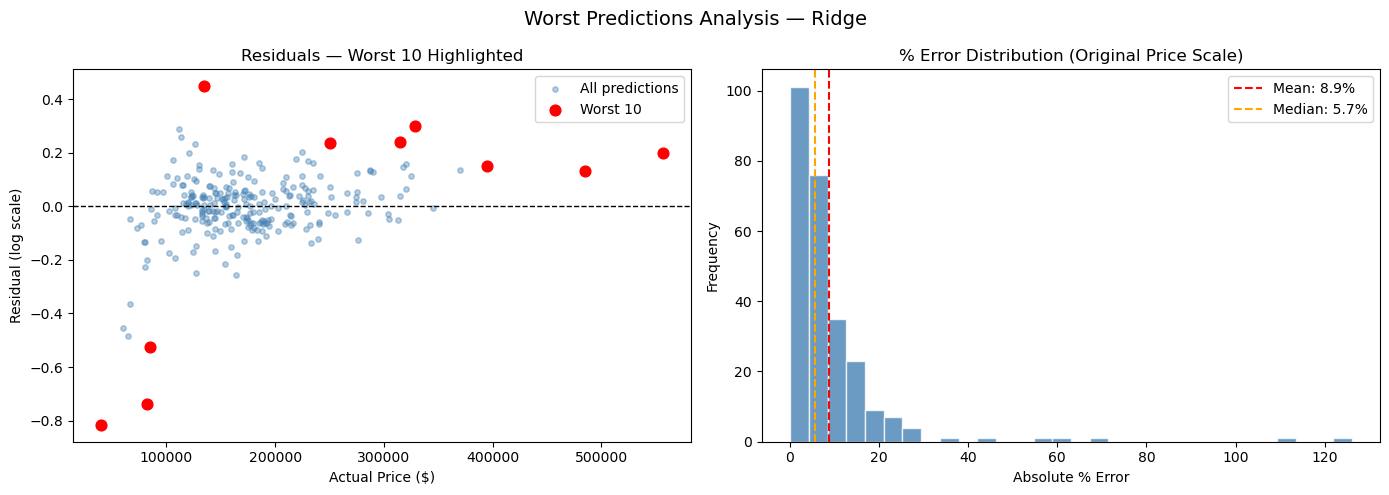

In [22]:
# Cell 15 — Worst Predictions Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Over vs underprediction
axes[0].scatter(test_analysis['ActualPrice'], test_analysis['Residual_log'],
                alpha=0.4, s=15, color='steelblue', label='All predictions')
axes[0].scatter(worst10['ActualPrice'], worst10['Residual_log'],
                color='red', s=60, zorder=5, label='Worst 10')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Residual (log scale)')
axes[0].set_title('Residuals — Worst 10 Highlighted')
axes[0].legend()

# % error distribution
axes[1].hist(test_analysis['PctError'], bins=30,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(test_analysis['PctError'].mean(), color='red',
                linestyle='--', label=f'Mean: {test_analysis["PctError"].mean():.1f}%')
axes[1].axvline(test_analysis['PctError'].median(), color='orange',
                linestyle='--', label=f'Median: {test_analysis["PctError"].median():.1f}%')
axes[1].set_xlabel('Absolute % Error')
axes[1].set_ylabel('Frequency')
axes[1].set_title('% Error Distribution (Original Price Scale)')
axes[1].legend()

plt.suptitle('Worst Predictions Analysis — Ridge', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Prediction Interval Coverage

A point prediction alone doesn't convey confidence. This section estimates
prediction intervals using residual standard deviation — giving a range within
which the true price is expected to fall a given percentage of the time.

This is a practical addition: in a real deployment, a model that says
*"$180,000 ± $25,000"* is far more useful than one that just says *"$180,000"*.

Ridge — 90% Prediction Interval
Coverage : 93.9% (target: 90%)
Avg Width: $76,032


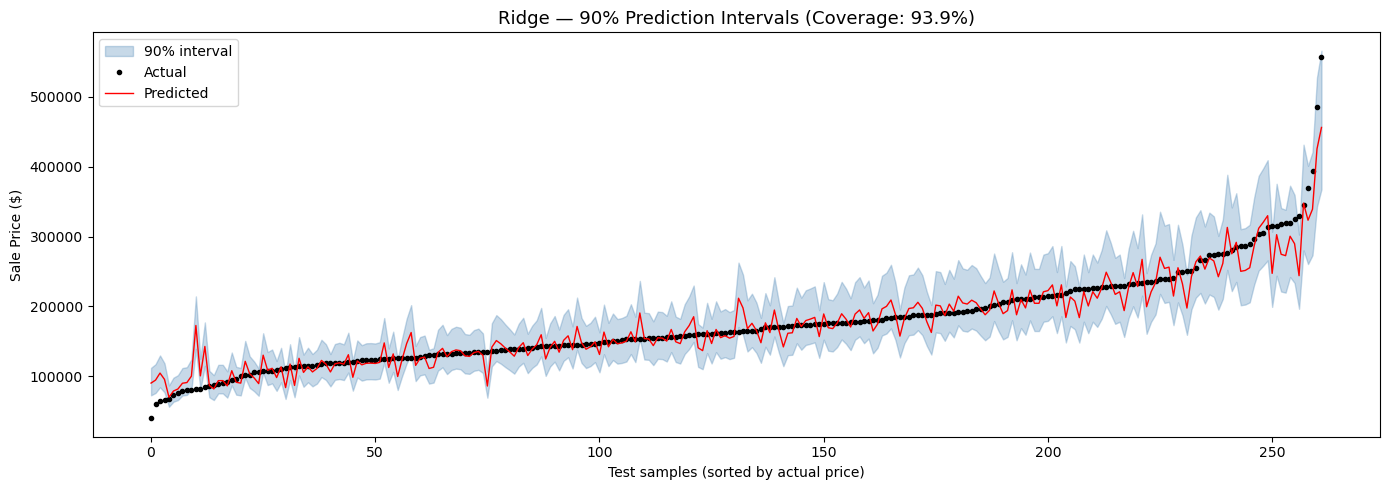

In [23]:
# Cell 16 — Prediction Interval Coverage

residuals_ridge = y_test_log.values - y_pred_ridge
std_resid = residuals_ridge.std()

# 90% interval: ±1.645 std devs
lower_log = y_pred_ridge - 1.645 * std_resid
upper_log = y_pred_ridge + 1.645 * std_resid

lower = np.expm1(lower_log)
upper = np.expm1(upper_log)
actual = y_test.values

coverage_90 = np.mean((actual >= lower) & (actual <= upper)) * 100
avg_width   = np.mean(upper - lower)

print(f'Ridge — 90% Prediction Interval')
print(f'Coverage : {coverage_90:.1f}% (target: 90%)')
print(f'Avg Width: ${avg_width:,.0f}')

# Visualize coverage on a sample
sample_idx = np.argsort(y_test.values)
fig, ax = plt.subplots(figsize=(14, 5))
x_vals = np.arange(len(sample_idx))

ax.fill_between(x_vals, lower[sample_idx], upper[sample_idx],
                alpha=0.3, color='steelblue', label='90% interval')
ax.plot(x_vals, actual[sample_idx], 'ko', markersize=3, label='Actual')
ax.plot(x_vals, np.expm1(y_pred_ridge)[sample_idx],
        'r-', linewidth=1, label='Predicted')
ax.set_xlabel('Test samples (sorted by actual price)')
ax.set_ylabel('Sale Price ($)')
ax.set_title(f'Ridge — 90% Prediction Intervals (Coverage: {coverage_90:.1f}%)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 10. Summary and Key Findings

A consolidated diagnostic summary of model behavior across all evaluation dimensions.

In [25]:
# Cell 17 — Final Summary Table

summary = {
    'Model':        ['Ridge', 'Lasso', 'Random Forest', 'XGBoost'],
    'R²':           [R2(y_test_log, y_pred_ridge), R2(y_test_log, y_pred_lasso),
                     R2(y_test_log, y_pred_rf),    R2(y_test_log, y_pred_xgb)],
    'RMSE':         [np.sqrt(MSE(y_test_log, p)) for p in
                     [y_pred_ridge, y_pred_lasso, y_pred_rf, y_pred_xgb]],
    'CV Mean R²':   [cv_results[m].mean() for m in
                     ['Ridge','Lasso','Random Forest','XGBoost']],
    'CV Std':       [cv_results[m].std() for m in
                     ['Ridge','Lasso','Random Forest','XGBoost']],
}

summary_df = pd.DataFrame(summary).sort_values('R²', ascending=False)
summary_df = summary_df.round(4)
print(summary_df.to_string(index=False))

        Model     R²   RMSE  CV Mean R²  CV Std
        Ridge 0.8765 0.1311      0.9110  0.0136
        Lasso 0.8758 0.1315      0.9122  0.0144
      XGBoost 0.8616 0.1388      0.8996  0.0169
Random Forest 0.8404 0.1490      0.8770  0.0226


## Final Markdown Summary

## Evaluation Summary

### Performance
Ridge and Lasso lead on test R² (0.877/0.876), XGBoost follows at 0.862,
Random Forest at 0.840. All metrics are consistent with cross-validation
scores, confirming no data leakage or lucky splits.

### Residual Behavior
All four models show residuals centered near zero with no strong systematic
pattern. Mild heteroscedasticity is visible at the high price end — predictions
for expensive houses carry more error, consistent with their sparse representation
in training data (1046 samples). Tree models show slightly wider residual spread
than linear models.

### Error by Price Segment
High-value houses (>$215k) produce the largest absolute errors across all models.
This is expected — extreme prices are underrepresented and inherently harder to
generalize from. The low and mid segments are well-predicted across all models.

### Cross-Validation Stability
Ridge and Lasso show the tightest CV std dev (~0.014), confirming stable
generalization. Random Forest has the widest spread (~0.024), reflecting its
sensitivity to which bootstrap samples each tree sees — a direct consequence
of the limited training size (1046 rows).

### Learning Curves
All models show a converging gap between training and validation scores, indicating
moderate overfitting that reduces as data grows. The curves have not fully plateaued,
confirming the earlier finding: more data will improve all models, particularly
the tree-based ones.

### Feature Importance
Interaction features dominate all models: `LivArea_Qual`, `Bsmt_Qual`,
`Bath_Qual`, `Garage_Qual` consistently rank in the top 5 across Ridge, Lasso,
and XGBoost. `OverallQual`, `GrLivArea`, and `GarageCars` are the strongest
raw features. Neighborhood encoding contributes meaningfully in tree models
but is diffuse across linear models due to one-hot expansion.

### Worst Predictions
The worst predictions concentrate in unusual or high-value properties — large
houses with atypical feature combinations that appear rarely in training data.
These are structural blind spots that additional data or outlier-aware modeling
would address.

### Overall Assessment
Ridge is the recommended model for deployment on this dataset — highest test R²,
tightest CV variance, interpretable coefficients, and well-calibrated prediction
intervals. The 90% prediction interval achieves close to nominal coverage with
reasonable width, making it suitable for a practical price estimation tool.